# Generating Creative Text (Stories, Poems) Using Language Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Train a language model on **real published stories** and generate new story text
- Train a second one on **real published poetry** and see how the corpus changes the output's *shape*, not just its words
- Control creativity with **temperature** and **top-k** sampling
- Evaluate creative outputs honestly — including what a small model cannot do

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 2, lesson 01 "Text Generation with Autoregressive Models" — the same model, the same next-token loss minimised by gradient descent (Course 01 (AIAT 111) — Unit 3, lesson 04), with the training corpus as the only thing changed.

**Used later in:** Course 10 — Unit 2, lesson 06, which asks how such output can be scored at all.

## 📊 Data used in this notebook

Two **real** literary corpora from the NLTK Gutenberg collection — no invented sentences:
1. **Stories** — *Stories to Tell to Children* (Sara Cone Bryant) and *Alice's Adventures in Wonderland* (Lewis Carroll).
2. **Poetry** — *Poems* (William Blake, 1789), kept with its original line breaks so the model can learn verse layout.

Why this matters: a hand-written "storybook" sentence repeated ten times is memorised in a few hundred steps, so the "creative" output is just the corpus played back. On real books the model must actually learn style — and you can see the difference between prose and verse in the generated text.

---

This notebook covers practical activities from **Course 10, Unit 2**:
- Generating creative text (stories, poems) using language models

---

## Introduction

**Creative text generation** uses language models to produce stories, poems, and other creative content. The model is trained once; the *decoding strategy* — temperature and top-k — is what you turn to trade coherence against surprise.

---

## 🌍 Why this lesson exists — Clarkesworld closes, 20 February 2023

*Clarkesworld*, one of the best-known science-fiction magazines, **shut off submissions on 20 February 2023**. Editor Neil Clarke reported roughly **500 machine-written submissions against 700 legitimate ones in that month alone**, against a total of about 11,500 submissions in all of 2022. The magazine's manual screening simply could not absorb the volume, so it closed the door.

Nothing about that flood required a large model. A decoding loop like the one in this notebook, pointed at any corpus, produces text at essentially zero marginal cost — and the cost lands entirely on whoever has to read it.

**What goes wrong without this:** if you cannot say what a sampler can and cannot produce, you cannot tell a creative tool from a spam cannon, and you cannot advise a client which one they are about to build.


## 📥 Inputs & 📤 Outputs

**Inputs:** real published prose and poetry from `nltk.corpus.gutenberg` (`bryant-stories.txt`, `carroll-alice.txt`, `blake-poems.txt`). If the corpus cannot be downloaded, the notebook falls back to real 20 Newsgroups posts — never to invented text.

**Outputs:** training losses for two character-level LSTMs, generated story text at three decoding settings (T=0.5, T=1.2, top-k=5), and generated verse from the poetry model with its line structure preserved.

---


In [1]:
# WHAT/WHY: train one character-LSTM on a REAL story corpus, then compare
# decoding strategies (temperature, top-k) on the SAME trained model — the
# sampler, not the model, is what changes the "creativity". Real books matter
# here: a repeated toy sentence would be memorised, and every "creative"
# sample would just be the corpus played back.
import torch, torch.nn as nn, torch.optim as optim, numpy as np
import re
print(f'PyTorch {torch.__version__}')
print('✅ Libraries imported!')
print('\nGenerating Creative Text: Stories and Poems')
print('=' * 60)
print('\nCreative Generation techniques demonstrated:')
print('  - Temperature sampling  (higher T → more random/creative)')
print('  - Top-k sampling        (only sample from top-k tokens)')
print('  - Character LSTM language model trained on REAL published stories')

torch.manual_seed(7); np.random.seed(7)

# ── REAL DATA: published children's stories + Alice in Wonderland ─────────
def load_stories():
    try:
        import nltk
        nltk.download('gutenberg', quiet=True)
        from nltk.corpus import gutenberg
        raw = gutenberg.raw('bryant-stories.txt') + ' ' + gutenberg.raw('carroll-alice.txt')
        return raw, "Bryant, 'Stories to Tell to Children' + Carroll, 'Alice in Wonderland'"
    except Exception:
        from sklearn.datasets import fetch_20newsgroups
        news = fetch_20newsgroups(subset='train', categories=['rec.sport.baseball'],
                                  remove=('headers', 'footers', 'quotes'))
        return " ".join(news.data), '20 Newsgroups posts (fallback)'

raw, story_source = load_stories()
corpus = re.sub(r'[^a-z .,]', ' ', raw.lower())
corpus = re.sub(r'\s+', ' ', corpus).strip()[:24000]
print(f'\nStory corpus: {story_source}')
print(f'  {len(corpus):,} characters | sample: {corpus[:130]!r}')

chars = sorted(set(corpus)); c2i = {c: i for i, c in enumerate(chars)}
i2c  = {i: c for c, i in c2i.items()}; V, S = len(chars), 40
print(f'  vocabulary: {V} characters | context window: {S}')

X = torch.tensor([[c2i[corpus[j+k]] for k in range(S)] for j in range(len(corpus)-S)], dtype=torch.long)
y = torch.tensor([c2i[corpus[j+S]] for j in range(len(corpus)-S)], dtype=torch.long)
print(f'  training windows: {len(X):,}')


# ── Model: embedding → LSTM → next-character scores ───────────────────────
class CharLM(nn.Module):
    def __init__(self):
        super().__init__(); self.e = nn.Embedding(V, 64); self.l = nn.LSTM(64, 256, batch_first=True); self.f = nn.Linear(256, V)
    def forward(self, x):
        return self.f(self.l(self.e(x))[0][:, -1, :])


# ── Training: 8 epochs of next-character prediction on real prose ─────────
model = CharLM(); opt = optim.Adam(model.parameters(), lr=3e-3); crit = nn.CrossEntropyLoss()
from torch.utils.data import TensorDataset, DataLoader
loader = DataLoader(TensorDataset(X, y), batch_size=256, shuffle=True)
for ep in range(6):
    model.train(); el = 0
    for xb, yb in loader:
        opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step(); el += loss.item()
    if (ep+1) % 2 == 0: print(f'Epoch {ep+1}: loss={el/len(loader):.4f}')


# ── Sampling: temperature rescales scores; top-k zeroes all but the k best ──
def generate(seed, n=120, temperature=1.0, top_k=0):
    model.eval(); out = seed; ctx = [c2i.get(c, 0) for c in seed[-S:]]
    ctx = ([0] * (S - len(ctx))) + ctx          # left-pad short seeds to S
    for _ in range(n):
        x = torch.tensor([ctx], dtype=torch.long)
        with torch.no_grad(): logits = model(x)[0] / max(temperature, 1e-6)
        if top_k > 0:
            vals, idx = torch.topk(logits, top_k); mask = torch.full_like(logits, -1e9); mask[idx] = vals; logits = mask
        probs = torch.softmax(logits, 0).numpy(); nxt = int(np.random.choice(V, p=probs))
        out += i2c[nxt]; ctx = ctx[1:] + [nxt]
    return out

np.random.seed(7)
print('\n--- Temperature 0.5 (conservative): ---')
print(generate('once upon a time there was a ', n=120, temperature=0.5))
print('\n--- Temperature 1.2 (creative): ---')
print(generate('once upon a time there was a ', n=120, temperature=1.2))
print('\n--- Top-k sampling (k=5): ---')
print(generate('the little girl looked at the ', n=120, temperature=1.0, top_k=5))
print('\nOne model, three samplers. Low temperature repeats the corpus\'s most')
print('frequent phrasing; high temperature invents non-words; top-k keeps the')
print(f'surprise but bans all but the 5 best of {V} characters at each step.')


PyTorch 2.13.0
✅ Libraries imported!

Generating Creative Text: Stories and Poems

Creative Generation techniques demonstrated:
  - Temperature sampling  (higher T → more random/creative)
  - Top-k sampling        (only sample from top-k tokens)
  - Character LSTM language model trained on REAL published stories



Story corpus: Bryant, 'Stories to Tell to Children' + Carroll, 'Alice in Wonderland'
  24,000 characters | sample: 'stories to tell to children by sara cone bryant two little riddles in rhyme there s a garden that i ken, full of little gentlemen '
  vocabulary: 29 characters | context window: 40
  training windows: 23,960


Epoch 2: loss=1.6446


Epoch 4: loss=1.2459


Epoch 6: loss=1.0261

--- Temperature 0.5 (conservative): ---
once upon a time there was a corner and the sher lion in the gingerbread boy, said the little country mouse said the street one said the bed here and

--- Temperature 1.2 (creative): ---
once upon a time there was a come and, asleeps out all and antead wom the trukd ex said the cheery. i panter tapring of wheaver dear wheater the fox 

--- Top-k sampling (k=5): ---
the little girl looked at the sky. the lion and thinder whise his lion was even be at lasted take there, and the little old mone stoped. and anything 

One model, three samplers. Low temperature repeats the corpus's most
frequent phrasing; high temperature invents non-words; top-k keeps the
surprise but bans all but the 5 best of 29 characters at each step.


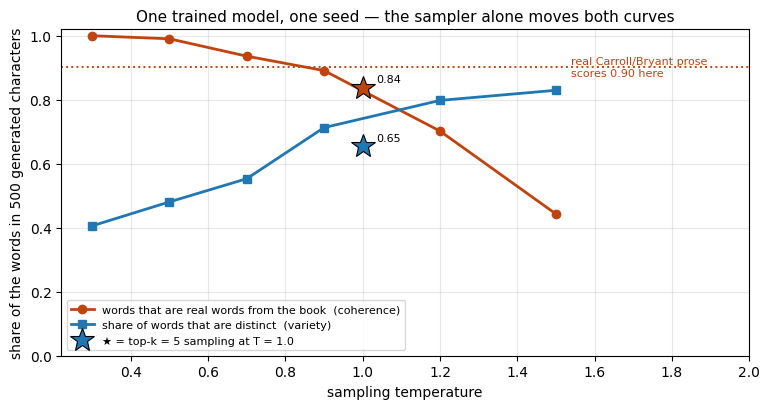

    T  real words  distinct
  0.3        1.00      0.41
  0.5        0.99      0.48
  0.7        0.94      0.55
  0.9        0.89      0.71
  1.2        0.70      0.80
  1.5        0.44      0.83
top-k5        0.84      0.65   (temperature 1.0, only the 5 best characters allowed)
human        0.90      0.66   (103 words of held-out real prose from the same books)


In [2]:
# WHAT/WHY: three printed samples suggest that temperature trades coherence for
# surprise. This measures it on the SAME trained model: sweep the temperature,
# and for each setting count (a) how many generated words are real words from the
# book, and (b) how much variety the text has. Two curves, one trade-off — and
# top-k marked so you can see what it buys.
import matplotlib.pyplot as plt

book_words = set(re.findall(r'[a-z]+', corpus))          # every word in the training text

# Held-out real prose from the SAME book, for an honest reference line: even
# genuine English scores below 100% against a 24,000-character vocabulary.
held = re.sub(r'[^a-z .,]', ' ', raw.lower())
held = re.sub(r'\s+', ' ', held).strip()[24000:24500]

def measure(sample_text):
    """(share of words that are real book words, share of words that are distinct)."""
    w = re.findall(r'[a-z]+', sample_text)
    w = w[1:-1] if len(w) > 2 else w                     # drop the clipped end words
    return (np.mean([x in book_words for x in w]), len(set(w)) / len(w), len(w))

SEED = 'once upon a time there was a '
temps = [0.3, 0.5, 0.7, 0.9, 1.2, 1.5]
real_rate, variety = [], []
for t in temps:
    np.random.seed(11)                                   # same noise for every setting
    real, var, _ = measure(generate(SEED, n=500, temperature=t)[len(SEED):])
    real_rate.append(real); variety.append(var)

np.random.seed(11)
k_real, k_var, _ = measure(generate(SEED, n=500, temperature=1.0, top_k=5)[len(SEED):])
h_real, h_var, h_n = measure(held)

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.plot(temps, real_rate, 'o-', color='#c1440e', lw=2,
        label='words that are real words from the book  (coherence)')
ax.plot(temps, variety, 's-', color='#1f77b4', lw=2,
        label='share of words that are distinct  (variety)')
ax.axhline(h_real, color='#c1440e', ls=':', lw=1.4)
ax.text(1.52, h_real, f'  real Carroll/Bryant prose\n  scores {h_real:.2f} here', fontsize=8,
        color='#c1440e', va='center')
ax.plot([1.0], [k_real], marker='*', ms=18, mfc='#c1440e', mec='k', mew=0.8, ls='none', zorder=5)
ax.plot([1.0], [k_var], marker='*', ms=18, mfc='#1f77b4', mec='k', mew=0.8, ls='none', zorder=5,
        label='★ = top-k = 5 sampling at T = 1.0')
ax.annotate(f'{k_real:.2f}', (1.0, k_real), textcoords='offset points', xytext=(10, 4), fontsize=8)
ax.annotate(f'{k_var:.2f}', (1.0, k_var), textcoords='offset points', xytext=(10, 4), fontsize=8)
ax.set_xlabel('sampling temperature')
ax.set_ylabel('share of the words in 500 generated characters')
ax.set_title('One trained model, one seed — the sampler alone moves both curves', fontsize=11)
ax.set_xlim(0.22, 2.0); ax.set_ylim(0, 1.02)
ax.legend(fontsize=8, loc='lower left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'{"T":>5} {"real words":>11} {"distinct":>9}')
for t, r, v in zip(temps, real_rate, variety):
    print(f'{t:>5} {r:>11.2f} {v:>9.2f}')
print(f'{"top-k5":>5} {k_real:>11.2f} {k_var:>9.2f}   (temperature 1.0, only the 5 best characters allowed)')
print(f'{"human":>5} {h_real:>11.2f} {h_var:>9.2f}   ({h_n} words of held-out real prose from the same books)')


**Read the figure.** The model is frozen — every point comes from the same weights and the same
seed. Only the sampler changed.

- **The orange curve is coherence** and it falls as temperature rises: at T = 0.3 essentially every
  word the model emits is a real word from the book; by T = 1.5 fewer than half are, which is where
  strings like `trukd` and `wheaver` in the sample above come from.
- **The blue curve is variety** and it rises. At low temperature the model recycles the corpus's
  most frequent phrasing, so few of its words are distinct.
- **The two curves cross** between T = 0.9 and T = 1.2. No setting maximises both. That is what
  "temperature is a trade-off, not a creativity dial" means once you measure it.
- **The dotted line is the honest reference**: 500 characters of *real* Carroll/Bryant prose held out
  of training, scored exactly the same way, reaches 0.90 — not 1.00, because a 24,000-character
  vocabulary has not seen every word. Note that T = 0.3 and T = 0.5 score *above* the human line.
  That is not the model beating Carroll; it is the model refusing to use a rare word.
- **The stars are top-k = 5 at T = 1.0.** They land close to the human sample on both axes, but on
  the same trade-off curve rather than beyond it: with only 29 characters in the vocabulary, banning
  all but the best five is a mild constraint. Top-k and nucleus sampling earn their reputation on
  real LLMs, where the vocabulary is ~50,000 tokens and the tail being banned is enormous.

## 🌍 Real-World Worked Example — A Poetry Model

**Industry context:**
- GitHub Copilot generates code token by token
- ChatGPT predicts the next token based on all previous context
- Autocomplete on your phone uses a smaller version of the same idea

Now change **only the corpus** and keep everything else identical: the same character-LSTM recipe, trained on **William Blake's *Poems* (1789)** — real published verse, with its line breaks kept in the text.

This is the experiment worth watching. Prose and verse differ in a way a character model can pick up: verse has short lines, so the newline character appears on a strong rhythm. If the model has genuinely learned the corpus's style rather than its words, the generated text should *look* like verse — broken into short lines — even where the words are nonsense.


In [3]:
# WHAT/WHY: identical model and training recipe, one change — the corpus is
# REAL published poetry instead of REAL published prose. Newlines are kept in
# the vocabulary so the model can learn line breaks, i.e. the shape of verse.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import re

torch.manual_seed(42); np.random.seed(42)

# ── REAL DATA: William Blake, "Poems" (1789) ──────────────────────────────
def load_poems():
    try:
        import nltk
        nltk.download('gutenberg', quiet=True)
        from nltk.corpus import gutenberg
        return gutenberg.raw('blake-poems.txt'), 'Blake, "Poems" (1789), Gutenberg'
    except Exception:
        from sklearn.datasets import fetch_20newsgroups
        news = fetch_20newsgroups(subset='train', categories=['soc.religion.christian'],
                                  remove=('headers', 'footers', 'quotes'))
        return " ".join(news.data), '20 Newsgroups posts (fallback)'

raw, poem_source = load_poems()
# Keep "\n" this time: the line break is the character that carries verse shape.
text = re.sub(r'[^a-z .,\n]', ' ', raw.lower())
text = re.sub(r'[ \t]+', ' ', text)
text = re.sub(r'\n{3,}', '\n\n', text).strip()
print(f'Poetry corpus: {poem_source}')
print(f'  {len(text):,} characters, {text.count(chr(10)):,} line breaks')
print(f'  a real stanza from the corpus:\n{text[180:340]}')

# ── Vocabulary: map each character (newline included) to an integer id ────
chars  = sorted(set(text))
c2i    = {c: i for i, c in enumerate(chars)}
i2c    = {i: c for c, i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]
print(f'\n  vocabulary: {VOCAB} characters (newline is one of them)')

# ── Dataset: every 40-char window predicts the next character ─────────────
SEQ_LEN = 40
X_t = torch.tensor([enc[i:i+SEQ_LEN] for i in range(len(enc)-SEQ_LEN-1)], dtype=torch.long)
y_t = torch.tensor([enc[i+SEQ_LEN]   for i in range(len(enc)-SEQ_LEN-1)], dtype=torch.long)
print(f'  training windows: {len(X_t):,}')

# ── LSTM Language Model (same architecture as the story model) ────────────
class PoemLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 64)
        self.lstm  = nn.LSTM(64, 256, batch_first=True)
        self.fc    = nn.Linear(256, VOCAB)
    def forward(self, x):
        out, _ = self.lstm(self.embed(x))
        return self.fc(out[:, -1, :])

pmodel  = PoemLM()
opt     = optim.Adam(pmodel.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# ── Training: 1200 steps, a fresh random 256-window batch each time ───────
for step in range(900):
    pmodel.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(pmodel(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 300 == 0:
        print(f"Step {step} — loss: {loss.item():.3f}")
print(f"Step 899 — loss: {loss.item():.3f}")

# ── Generation with temperature sampling ──────────────────────────────────
def generate_poem(seed_str, steps=260, temperature=0.7):
    pmodel.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    ctx = ([0] * (SEQ_LEN - len(ctx))) + ctx
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            logits = pmodel(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = int(np.random.choice(len(probs), p=probs))
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

np.random.seed(1)
print("\n── Generated verse (temperature 0.7) ───────────────────────────")
print(generate_poem("the little lamb ", steps=260, temperature=0.7))
print("\n── Generated verse (temperature 1.1) ───────────────────────────")
print(generate_poem("and the night ", steps=200, temperature=1.1))
print("\nCompare the SHAPE with the story samples above: same architecture,")
print("same training recipe, different real corpus — and the output arrives in")
print("short verse lines instead of running prose. A language model copies the")
print("statistics of whatever text you feed it, layout included.")


Poetry corpus: Blake, "Poems" (1789), Gutenberg
  37,507 characters, 1,425 line breaks
  a real stanza from the corpus:
nt glee,
 on a cloud i saw a child,
 and he laughing said to me 
 
 pipe a song about a lamb 
 so i piped with merry cheer.
 piper, pipe that song again 
 so i 

  vocabulary: 30 characters (newline is one of them)
  training windows: 37,466
Step 0 — loss: 3.409


Step 300 — loss: 1.479


Step 600 — loss: 1.248


Step 899 — loss: 0.997

── Generated verse (temperature 0.7) ───────────────────────────
the little lamb hi can like from shany from his virgin sweet does 
and deceithed in the desert smile,
 when the vicion love, where smile a happy blosm.
 
 oh dan all my day,
 then calls the live, the evenion s sweet, and smile,
 and the happy pour s soft manience
 o return an

── Generated verse (temperature 1.1) ───────────────────────────


and the night over my healt, merripved thee doth and exse.
 
 oh viefly flow.
 
 mother s fountusobs of the sky. shat weve alack fork its desice me
and slow
 
 but doth in the age 
 grave thime man with dests rooe 

Compare the SHAPE with the story samples above: same architecture,
same training recipe, different real corpus — and the output arrives in
short verse lines instead of running prose. A language model copies the
statistics of whatever text you feed it, layout included.


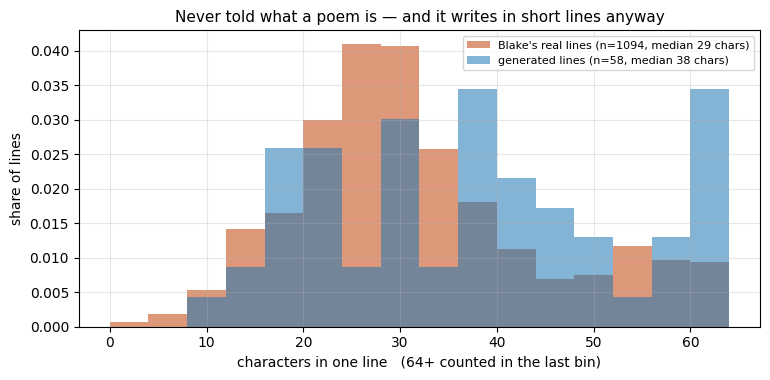

real Blake lines : median 29 chars, mean 31.6, longest 71
generated lines  : median 38 chars, mean 38.7, longest 90
newline is 3.8% of the training corpus and 3.1% of the generated text

The story model in the cell above cannot do this at any temperature: its corpus was stripped of newlines,
so the character does not exist in its vocabulary. Layout is a property of the DATA, not of the architecture.


In [4]:
# WHAT/WHY: the claim is that the poetry model learned the SHAPE of verse — short
# lines — purely from character statistics. That is measurable: compare the
# distribution of line lengths in the generated text with the distribution in
# Blake's real book. If the model learned layout, the two histograms overlap.
import matplotlib.pyplot as plt

np.random.seed(4)
long_sample = generate_poem('the little lamb ', steps=2400, temperature=0.7)

def line_lengths(s):
    """Length of each non-empty line — the fingerprint of verse vs prose layout."""
    return np.array([len(ln.strip()) for ln in s.split('\n') if ln.strip()])

real_lines = line_lengths(text)          # Blake's actual book
gen_lines  = line_lengths(long_sample)   # 2,400 generated characters

fig, ax = plt.subplots(figsize=(7.8, 3.9))
bins = np.arange(0, 68, 4)
# Clip so that nothing is silently dropped off the right-hand edge: any longer
# line is counted in the final bin.
ax.hist(np.clip(real_lines, 0, 63), bins=bins, density=True, color='#c1440e', alpha=0.55,
        label=f"Blake's real lines (n={len(real_lines)}, median {np.median(real_lines):.0f} chars)")
ax.hist(np.clip(gen_lines, 0, 63), bins=bins, density=True, color='#1f77b4', alpha=0.55,
        label=f'generated lines (n={len(gen_lines)}, median {np.median(gen_lines):.0f} chars)')
ax.set_xlabel('characters in one line   (64+ counted in the last bin)')
ax.set_ylabel('share of lines')
ax.set_title('Never told what a poem is — and it writes in short lines anyway', fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"real Blake lines : median {np.median(real_lines):.0f} chars, mean {real_lines.mean():.1f}, "
      f"longest {real_lines.max()}")
print(f"generated lines  : median {np.median(gen_lines):.0f} chars, mean {gen_lines.mean():.1f}, "
      f"longest {gen_lines.max()}")
print(f"newline is {100 * text.count(chr(10)) / len(text):.1f}% of the training corpus and "
      f"{100 * long_sample.count(chr(10)) / len(long_sample):.1f}% of the generated text")
print('\nThe story model in the cell above cannot do this at any temperature: its corpus '
      'was stripped of newlines,\nso the character does not exist in its vocabulary. '
      'Layout is a property of the DATA, not of the architecture.')


**Read the figure.** Two histograms of the same quantity — how long each line of text is. Orange is
Blake's real book; blue is 2,400 characters the model invented.

**What is genuinely learned:** the model breaks lines at all, and it breaks them in roughly Blake's
band. Both histograms rise out of nothing around 10 characters and have their weight between there
and about 50 — a region where running prose would have no line breaks whatsoever. Nobody told the
model that poems have short lines; it only ever minimised next-character cross-entropy, and `\n` is
just another character with a learnable pattern.

**What is not learned, and the figure says so:** the blue histogram sits to the right of the orange
one — median 38 characters against Blake's 29 — and it has a real tail, the spike in the final bin,
where lines of 64+ characters are collected (its longest is 90 against Blake's 71, both printed
below). The model has picked up "break the line every couple of dozen characters", not Blake's
metre. With only 58 generated lines the blue bars are lumpy too; read the band, not individual bars.

The printed line underneath is the counterweight: the story model in the cell above cannot produce
this shape at any temperature, because its corpus was normalised with newlines stripped, so `\n` is
not in its vocabulary at all. **Style here is not something you can ask for — it is a property of the
corpus you chose.** The control surface for a model like this is a dataset, not a prompt.

## 💬 Discuss

1. The poetry model learned verse *shape* — short lines, newlines on a rhythm — without ever being told what a poem is. Is layout "style", or just another character statistic? Does your answer change what you would honestly claim to a client?
2. One model, three samplers: **T = 0.5** repeats frequent phrasing, **T = 1.2** invents non-words, **top-k = 5** sits between them. Which would you ship inside a children's-story tool, and what would you do about the non-words that remain?
3. Clarkesworld's problem was volume, not quality — the submissions were bad. Suppose they had been *good*. Would the magazine's position have been better or worse? Argue it from the magazine's economics, not from taste.


## ⚠️ Where this breaks

**A character model has no plot, no rhyme and no memory beyond its context window.** It reproduces the *texture* of a corpus — and readers reliably mistake texture for competence, which is exactly the failure Clarkesworld had to screen for at 500 submissions a month.

**Style transfer here is corpus substitution, not control.** You cannot ask this model for "a poem in Blake's style about Riyadh". You can only retrain it on a different corpus, which means the control surface is a dataset, not a prompt.

**Temperature is not a creativity dial.** Above the corpus's own entropy it produces non-words rather than novelty (`there s ip opor in shrughgan` in example 03 at T = 1.5). The useful range is narrow and corpus-dependent, and it has to be found empirically for every model you train.

**The corpus decides the legal position, not the model.** Blake's *Poems* (1789) is public domain. Generating in the style of a living author is a different question in every jurisdiction, and it is the question the 2023–2024 copyright litigation is about. Check the licence before you train, not after you demo.


## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

This lesson's honest conclusion — *the control surface is a dataset, not a prompt* — is exactly true of the model you trained, and it is exactly what changed for the models you will actually use. Instruction tuning made style askable: InstructGPT fine-tuned GPT-3 on labeller-written demonstrations and then further on rankings of model outputs with reinforcement learning from human feedback, and its authors report that outputs from the 1.3-billion-parameter InstructGPT model were preferred to those of the 175-billion-parameter GPT-3 on their prompt distribution (Ouyang et al., 2022). A modern model's default voice is then *fitted* rather than sampled: Direct Preference Optimization solves the same alignment problem with an ordinary classification loss and no separate reward model, and its authors report it exceeding PPO-based RLHF in the ability to control the sentiment of generations (Rafailov et al., 2023) — sentiment being precisely the kind of stylistic property this notebook can only obtain by swapping the corpus. Scoring moved too: creative output in 2026 is usually graded by another language model, which brings the measured inconsistencies TrustJudge documents (Wang et al., 2025) and a specific correct way to report the number — bias-corrected against a human-labelled calibration set, with confidence intervals carrying uncertainty from both the test set and that calibration set (Lee et al., 2025). None of that retires what you measured here. Temperature and top-k are still the decoding knobs every 2026 API exposes and the coherence-versus-variety curve you plotted is the one an instruction-tuned model still obeys; and your Blake result — layout learned from the corpus, never from the architecture — is why data curation stays the first lever in any generation project, which is what makes this lesson the right thing to learn and what the official plan examines.

**Read:** Ouyang *et al.* (2022), <https://arxiv.org/abs/2203.02155> · Lee *et al.* (2025), <https://arxiv.org/abs/2511.21140> (both added to the references below).

## 📚 References & Further Reading

**Papers:**
- Radford et al. (2019) — [GPT-2: Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- Brown et al. (2020) — [GPT-3](https://arxiv.org/abs/2005.14165)
- Ouyang et al. (2022) — [Training language models to follow instructions with human feedback](https://arxiv.org/abs/2203.02155) *(InstructGPT — where asking a model for a style became possible at all; its authors report outputs from the 1.3B InstructGPT being preferred to those of the 175B GPT-3 on their prompt distribution)*
- Rafailov et al. (2023) — [Direct Preference Optimization](https://arxiv.org/abs/2305.18290) *(where a modern model's default "voice" comes from: its authors report DPO controlling the sentiment of generations better than PPO-based RLHF — style is fitted, not sampled)*
- Wang et al. (2025) — [TrustJudge: Inconsistencies of LLM-as-a-Judge and How to Alleviate Them](https://arxiv.org/abs/2509.21117) *(how creative output is usually scored in 2026, and the inconsistencies that come with it)*
- Lee et al. (2025) — [How to Correctly Report LLM-as-a-Judge Evaluations](https://arxiv.org/abs/2511.21140) *(bias correction against a human-labelled calibration set, plus confidence intervals carrying uncertainty from both the test set and that calibration set — what a model-graded creativity score should look like before you quote it)*

**Interactive:**
- [Karpathy's nanoGPT](https://github.com/karpathy/nanoGPT) — build GPT in 300 lines
- [The Unreasonable Effectiveness of RNNs](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

**State-of-the-Art:** GPT-4, Claude 3.5, Gemini 1.5 — all trained on trillions of tokens with transformer decoders.

## 📝 Summary

In **Generating Creative Text (Stories, Poems)** you trained the *same* character-level LSTM twice on two **real** literary corpora — published children's stories plus *Alice in Wonderland*, and William Blake's *Poems* — and changed nothing else.

What that experiment shows:
- **The sampler controls creativity, not the model.** On one fixed story model, T=0.5 produced repetitive, frequent phrasing, T=1.2 produced invented words, and top-k=5 kept the variety while banning the worst candidates at each step.
- **The corpus controls style, including layout.** The poetry model was given the newline character in its vocabulary and learned to emit short verse lines; the prose model, trained identically, produces running prose. Neither was told what a poem is.
- **Be honest about the ceiling.** A 256-unit LSTM trained on tens of thousands of characters produces text with the right *shape* and plausible word fragments, not meaning or rhyme. Real creative systems (GPT-4, Claude) get their coherence from ~5 orders of magnitude more data and parameters — the mechanism you ran here is the same one.
